In [1]:
import sys, os, time, math, random
import multiprocessing
import numpy as np
import numba
from numba import njit,prange
from joblib import Parallel, delayed

In [2]:
#Base 
def mat_mult(a,b):
    out = [[0]*len(b[0]) for i in range(len(a))]

    for i in range(len(a)):
        for j in range(len(b[0])):
            for k in range(len(b)):
                out[i][j] += a[i][k] * b[k][j]
    return out

In [3]:
a = [[12, 7, 3],
     [4, 8, 6],
     [7, 11, 1]]

b = [[5, 8, 1, 2],
     [6, 13, 7, 20],
     [3, 5, 9, 14]]

%timeit mat_mult(a,b)

1.79 μs ± 9.74 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [4]:
def mat_mult_np(a,b):
    a = np.array(a)
    b = np.array(b)

    return np.matmul(a,b)

In [5]:
#Numba
@njit(nogil=True, parallel=True)
def mat_mult_numba(a,b):
    n = a.shape[0]
    m = b.shape[1]
    o = b.shape[0]
    
    out = np.zeros((n,m), dtype=np.float64)

    for i in prange(n):
        for j in range(m):
            for k in range(o):
                out[i,j] += a[i,k] * b[k][j]
    return out

In [6]:
mat_mult_numba(np.random.rand(128, 128), np.random.rand(128, 128))

array([[31.40921534, 29.17548427, 33.19427553, ..., 33.76604152,
        31.26202397, 28.42031314],
       [33.8276302 , 32.57897372, 32.94724989, ..., 36.86123524,
        32.98700548, 31.38626247],
       [33.70295699, 31.26618951, 31.79986651, ..., 36.63858113,
        31.50623641, 30.94405076],
       ...,
       [29.97232035, 27.90770056, 32.0507784 , ..., 33.7983885 ,
        30.03031626, 29.3066795 ],
       [31.87827407, 30.83150508, 33.50548556, ..., 35.38263189,
        33.03823293, 30.37251302],
       [32.3457954 , 30.23689695, 32.20905138, ..., 33.68859204,
        31.82571538, 29.95090301]], shape=(128, 128))

In [7]:
%load_ext Cython

In [8]:
%%cython
# code adapted from https://le.qun.ch/en/blog/cython/
from cython.parallel import prange
import numpy as np
cimport numpy as cnp
cimport cython

@cython.boundscheck(False)
@cython.wraparound(False)
def mat_mult_cython(cnp.ndarray[cnp.float64_t, ndim=2] a, cnp.ndarray[cnp.float64_t, ndim=2] b, int n_threads=1):
    cdef cnp.ndarray[cnp.float64_t, ndim=2] c
    cdef int n, p, m
    #cdef cnp.float64_t s
    cdef double[:, :] av = a, bv = b, cv
    if a.shape[1] != b.shape[0]:
        raise ValueError('shape not matched')
    n, p, m = a.shape[0], a.shape[1], b.shape[1]
    c = np.zeros((n, m), dtype=np.float64)
    cv = c
    with nogil:
        for i in prange(n, num_threads=n_threads, schedule='static'):
            for j in range(m):
                cv[i,j] = 0
                for k in range(p):
                    cv[i,j] += a[i, k] * b[k, j]
    return c


In [9]:

def matmult_chunk(a_chunk, b):
    return np.dot(a_chunk, b)

def mat_mult_joblib(a, b, n_jobs):
    chunks = np.array_split(a, n_jobs, axis=0)
    results = Parallel(n_jobs=n_jobs)(
        delayed(matmult_chunk)(chunk, b) for chunk in chunks
    )
    return np.vstack(results)

In [10]:
#multi
def matmult_worker(args):
    a_chunk, b = args
    return np.dot(a_chunk, b)

def mat_mult_multip(a, b, n_procs):
    chunks = np.array_split(a, n_procs, axis=0)
    with multiprocessing.Pool(n_procs) as pool:
        results = pool.map(matmult_worker, [(chunk, b) for chunk in chunks])
    return np.vstack(results)

In [11]:
numba.set_num_threads(1)

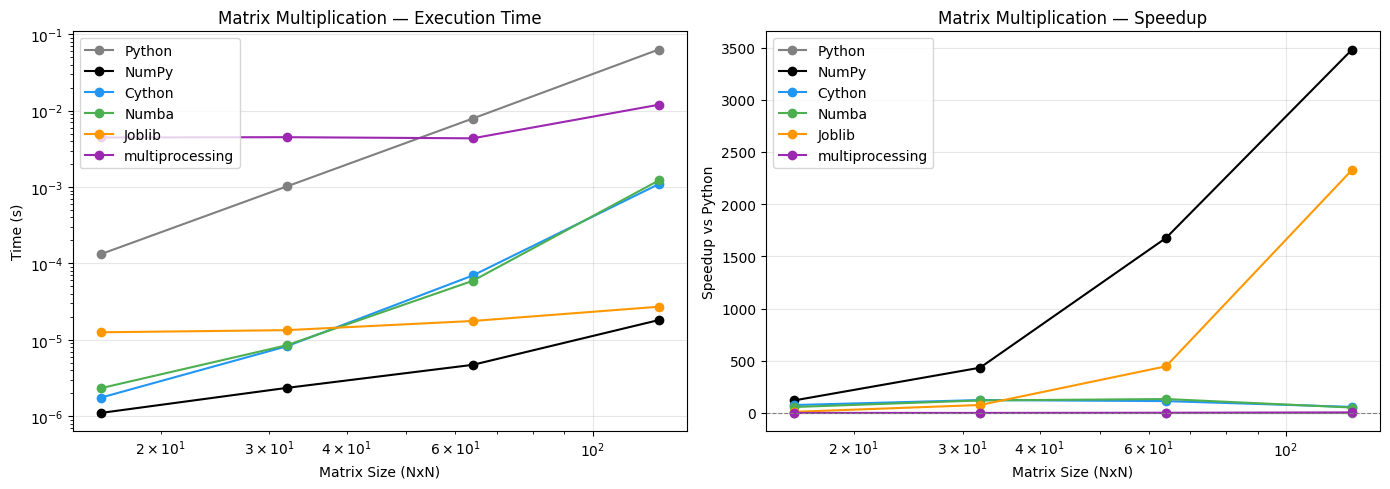

In [12]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [16, 32, 64, 128]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    a = np.random.rand(n, n).astype(np.float32)
    b = np.random.rand(n, n).astype(np.float32)
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)

    t = %timeit -o -q -n 5 mat_mult(a.tolist(), b.tolist())
    results['Python'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_np(a64, b64)
    results['NumPy'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_cython(a64, b64, 1)
    results['Cython'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_numba(a64, b64)
    results['Numba'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_joblib(a64, b64, 1)
    results['Joblib'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_multip(a64, b64, 1)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Matrix Size (NxN)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Matrix Multiplication — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Matrix Size (NxN)')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Matrix Multiplication — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_results_4.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
numba.set_num_threads(2)

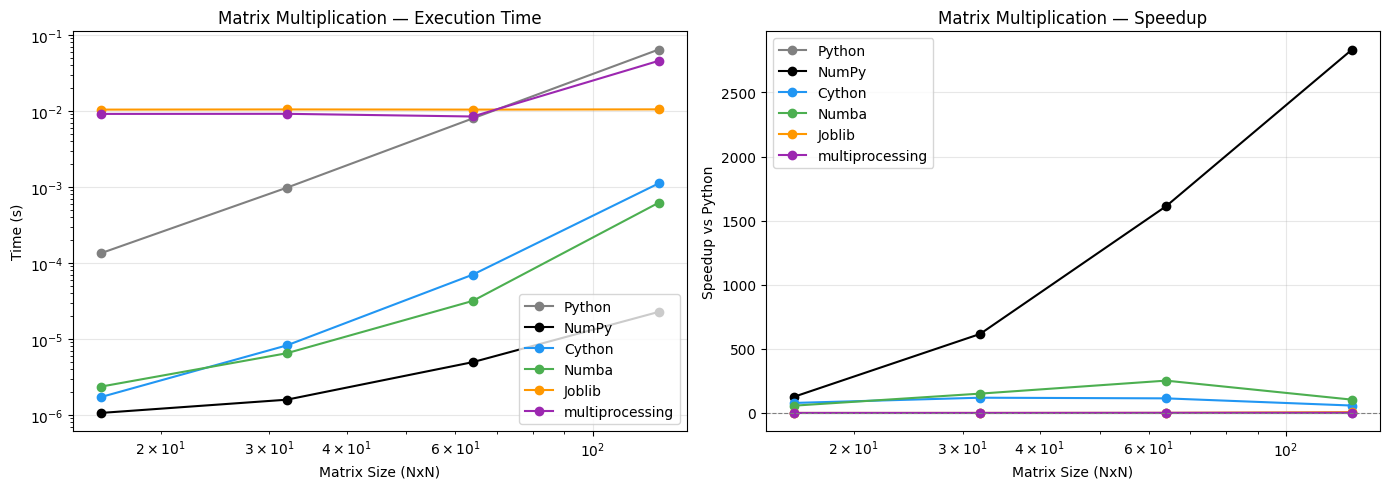

In [14]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [16, 32, 64, 128]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    a = np.random.rand(n, n).astype(np.float32)
    b = np.random.rand(n, n).astype(np.float32)
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)

    t = %timeit -o -q -n 5 mat_mult(a.tolist(), b.tolist())
    results['Python'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_np(a64, b64)
    results['NumPy'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_cython(a64, b64, 2)
    results['Cython'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_numba(a64, b64)
    results['Numba'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_joblib(a64, b64, 2)
    results['Joblib'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_multip(a64, b64, 2)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Matrix Size (NxN)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Matrix Multiplication — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Matrix Size (NxN)')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Matrix Multiplication — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_results_8.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
numba.set_num_threads(4)

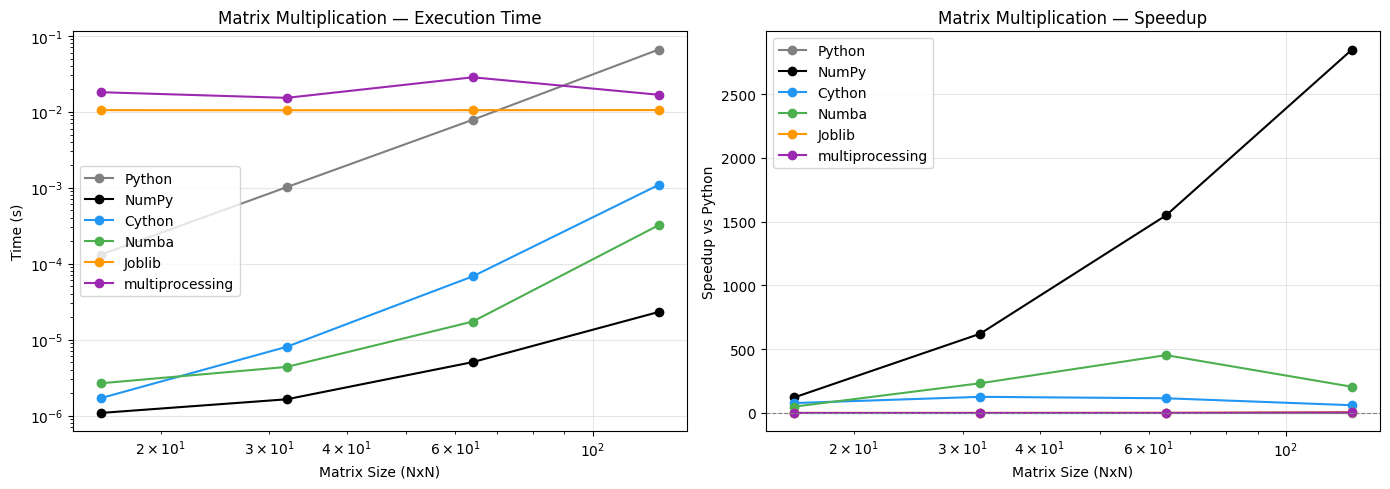

In [16]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [16, 32, 64, 128]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    a = np.random.rand(n, n).astype(np.float32)
    b = np.random.rand(n, n).astype(np.float32)
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)

    t = %timeit -o -q -n 5 mat_mult(a.tolist(), b.tolist())
    results['Python'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_np(a64, b64)
    results['NumPy'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_cython(a64, b64,4)
    results['Cython'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_numba(a64, b64)
    results['Numba'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_joblib(a64, b64, 4)
    results['Joblib'].append(t.best)

    t = %timeit -o -q -n 20 mat_mult_multip(a64, b64, 4)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Matrix Size (NxN)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Matrix Multiplication — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Matrix Size (NxN)')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Matrix Multiplication — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_results_16.png', dpi=150, bbox_inches='tight')
plt.show()